<a href="https://colab.research.google.com/github/raki-rankawat/stm32-thesis/blob/main/VGG_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# Imports
# =====================================================

import os
import time
import tarfile
import random
import shutil
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from google.colab import drive

In [2]:
# =====================================================
# Mount Google Drive
# =====================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =====================================================
# Device Setup
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(41)
random.seed(41)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("Device:", device)

Device: cuda


In [4]:
# =====================================================
# Dataset Configuration
# =====================================================

VWW_URL = "https://www.silabs.com/public/files/github/machine_learning/benchmarks/datasets/vw_coco2014_96.tar.gz"

BASE_DIR = Path("/content/vww_work")
ARCHIVE_PATH = BASE_DIR / "vw_coco2014_96.tar.gz"
EXTRACT_DIR = BASE_DIR / "extracted"
SUBSET_DIR = BASE_DIR / "vww_10k"

N_PER_CLASS = 5000
VAL_RATIO = 0.20

In [5]:
# =====================================================
# Download VWW Dataset
# =====================================================

def download_vww():

    BASE_DIR.mkdir(parents=True, exist_ok=True)

    if ARCHIVE_PATH.exists() and ARCHIVE_PATH.stat().st_size > 0:
        print("✅ VWW archive already downloaded")
        return

    print("⬇️ Downloading VWW archive...")
    urlretrieve(VWW_URL, ARCHIVE_PATH)
    print("✅ Download complete:", ARCHIVE_PATH)

In [6]:
# =====================================================
# Extract Dataset
# =====================================================

def extract_vww():

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    if any(EXTRACT_DIR.iterdir()):
        print("✅ VWW already extracted")
        return

    print("📦 Extracting VWW archive...")

    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(EXTRACT_DIR)

    print("✅ Extraction complete:", EXTRACT_DIR)

In [7]:
# =====================================================
# Locate Dataset Root
# =====================================================

def find_vww_root():

    for p in EXTRACT_DIR.rglob("person"):
        if p.is_dir() and (p.parent / "non_person").is_dir():
            return p.parent

    raise RuntimeError("❌ Could not find dataset directories")

In [8]:
# =====================================================
# Image Listing Helper
# =====================================================

def list_images(folder):

    exts = {".jpg", ".jpeg", ".png"}

    return [
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in exts
    ]

In [9]:
# =====================================================
# Create 10K Subset
# =====================================================

def make_vww_subset(src_root):

    if (SUBSET_DIR / "train" / "person").exists():
        print("✅ VWW subset already exists:", SUBSET_DIR)
        return

    for split in ["train", "val"]:
        for c in ["person", "non_person"]:
            (SUBSET_DIR / split / c).mkdir(parents=True, exist_ok=True)

    person_imgs = list_images(src_root / "person")
    nonperson_imgs = list_images(src_root / "non_person")

    if len(person_imgs) < N_PER_CLASS or len(nonperson_imgs) < N_PER_CLASS:
        raise ValueError("❌ Not enough images in dataset")

    random.shuffle(person_imgs)
    random.shuffle(nonperson_imgs)

    person_sel = person_imgs[:N_PER_CLASS]
    nonperson_sel = nonperson_imgs[:N_PER_CLASS]

    def split_list(lst):
        n_val = int(len(lst) * VAL_RATIO)
        return lst[n_val:], lst[:n_val]

    p_train, p_val = split_list(person_sel)
    n_train, n_val = split_list(nonperson_sel)

    def copy_files(files, dst):

        for f in files:
            target = dst / f.name

            if target.exists():
                target = dst / f"{f.parent.name}_{f.name}"

            shutil.copy2(f, target)

    print("🧩 Creating VWW subset...")

    copy_files(p_train, SUBSET_DIR / "train" / "person")
    copy_files(p_val,   SUBSET_DIR / "val"   / "person")
    copy_files(n_train, SUBSET_DIR / "train" / "non_person")
    copy_files(n_val,   SUBSET_DIR / "val"   / "non_person")

    print("✅ Subset created:", SUBSET_DIR)

In [10]:
# =====================================================
# Prepare Dataset
# =====================================================

download_vww()
extract_vww()

vww_root = find_vww_root()
print("Dataset root:", vww_root)

make_vww_subset(vww_root)

⬇️ Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
📦 Extracting VWW archive...


/tmp/ipykernel_896/1705152915.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


✅ Extraction complete: /content/vww_work/extracted
Dataset root: /content/vww_work/extracted/vw_coco2014_96
🧩 Creating VWW subset...
✅ Subset created: /content/vww_work/vww_10k


In [11]:
# =====================================================
# Data Loaders
# =====================================================

BATCH_SIZE = 64
IMG_SIZE = 96

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

train_data = datasets.ImageFolder(
    root=str(SUBSET_DIR / "train"),
    transform=train_transform
)

val_data = datasets.ImageFolder(
    root=str(SUBSET_DIR / "val"),
    transform=val_transform
)

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Class mapping:", train_data.class_to_idx)

Class mapping: {'non_person': 0, 'person': 1}


In [12]:
# =====================================================
# VGG-Style CNN for VWW
# =====================================================

class VWW_VGGStyle(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1 : 96 -> 48
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 2 : 48 -> 24
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 3 : 24 -> 12
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 4 : 12 -> 6
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

In [13]:
# =====================================================
# Model Initialization
# =====================================================

model = VWW_VGGStyle().to(device)

In [14]:
# =====================================================
# Loss, Optimizer, Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

In [15]:
# =====================================================
# Training Function
# =====================================================

def train(model, loader):

    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
        total += batch_size

    return running_loss / total, correct / total

In [16]:
# =====================================================
# Validation Function
# =====================================================

def validate(model, loader):

    model.eval()

    correct = 0
    total = 0
    running_loss = 0

    with torch.no_grad():
        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size

            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += batch_size

    return running_loss / total, correct / total

In [17]:
# =====================================================
# Training Loop
# =====================================================

EPOCHS = 50

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_acc = 0
best_epoch = 0
patience = 8
patience_counter = 0

best_path = "/content/drive/My Drive/Colab Notebooks/vww_vggstyle_model.pth"

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"LR {scheduler.get_last_lr()[0]:.6f} | "
        f"Train Loss {train_loss:.4f} | Train Acc {train_acc*100:.2f}% | "
        f"Val Loss {val_loss:.4f} | Val Acc {val_acc*100:.2f}%"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch
        patience_counter = 0

        torch.save(model.state_dict(), best_path)
        print("✅ Model saved")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("🛑 Early stopping triggered")
        break

print("Training time:", (time.time() - start_time) / 60, "minutes")
print("Best epoch:", best_epoch)
print("Best accuracy:", best_acc * 100)

Epoch 1/50 | LR 0.000999 | Train Loss 0.6655 | Train Acc 60.96% | Val Loss 0.7457 | Val Acc 59.50%
✅ Model saved
Epoch 2/50 | LR 0.000996 | Train Loss 0.6387 | Train Acc 64.90% | Val Loss 0.6177 | Val Acc 67.75%
✅ Model saved
Epoch 3/50 | LR 0.000991 | Train Loss 0.6252 | Train Acc 66.17% | Val Loss 0.6393 | Val Acc 66.40%
Epoch 4/50 | LR 0.000984 | Train Loss 0.6069 | Train Acc 68.21% | Val Loss 0.6406 | Val Acc 68.80%
✅ Model saved
Epoch 5/50 | LR 0.000976 | Train Loss 0.6000 | Train Acc 68.97% | Val Loss 0.5600 | Val Acc 70.85%
✅ Model saved
Epoch 6/50 | LR 0.000965 | Train Loss 0.5951 | Train Acc 69.33% | Val Loss 0.5768 | Val Acc 70.40%
Epoch 7/50 | LR 0.000952 | Train Loss 0.5836 | Train Acc 71.14% | Val Loss 0.6570 | Val Acc 64.95%
Epoch 8/50 | LR 0.000938 | Train Loss 0.5728 | Train Acc 71.56% | Val Loss 0.6249 | Val Acc 64.90%
Epoch 9/50 | LR 0.000922 | Train Loss 0.5618 | Train Acc 72.20% | Val Loss 0.5543 | Val Acc 71.85%
✅ Model saved
Epoch 10/50 | LR 0.000905 | Train Loss 

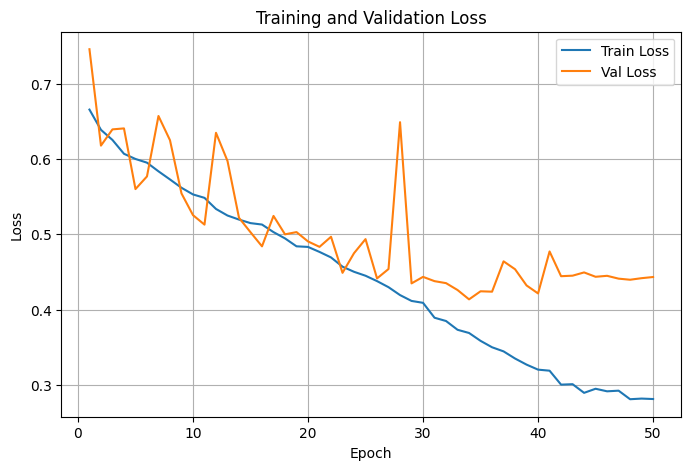

In [18]:
# =====================================================
# Loss Plot
# =====================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

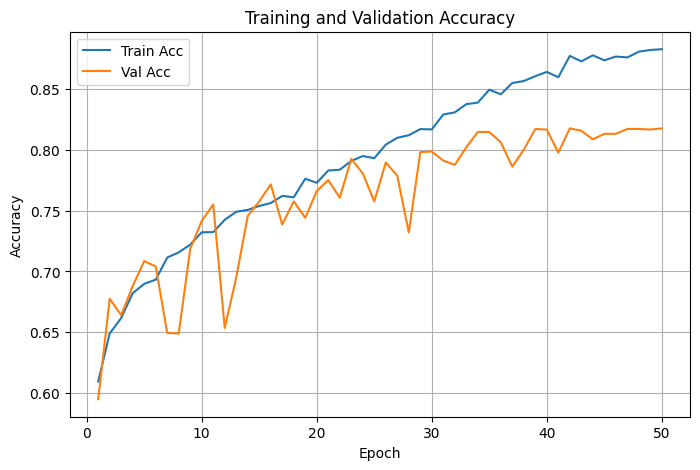

In [19]:
# =====================================================
# Accuracy Plot
# =====================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_accs) + 1), train_accs, label="Train Acc")
plt.plot(range(1, len(val_accs) + 1), val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# =====================================================
# Denormalize Images
# =====================================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

In [21]:
# =====================================================
# Show Specific Validation Images (One Row)
# =====================================================

classes = train_data.classes

def show_specific_images(indices):

    model.eval()
    num_images = len(indices)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):

        image, label = val_data[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}\n"
            f"{confidence.item()*100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

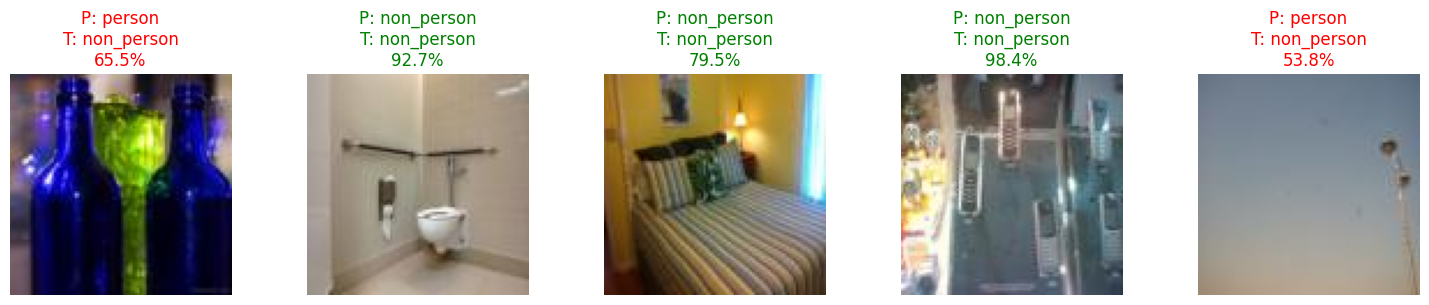

In [25]:
show_specific_images([10, 25, 100, 220, 500])

In [22]:
# =====================================================
# Show Random Validation Predictions (One Row)
# =====================================================

def show_random_predictions(num_images=5):

    model.eval()
    indices = random.sample(range(len(val_data)), num_images)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):

        image, label = val_data[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}\n"
            f"{confidence.item()*100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

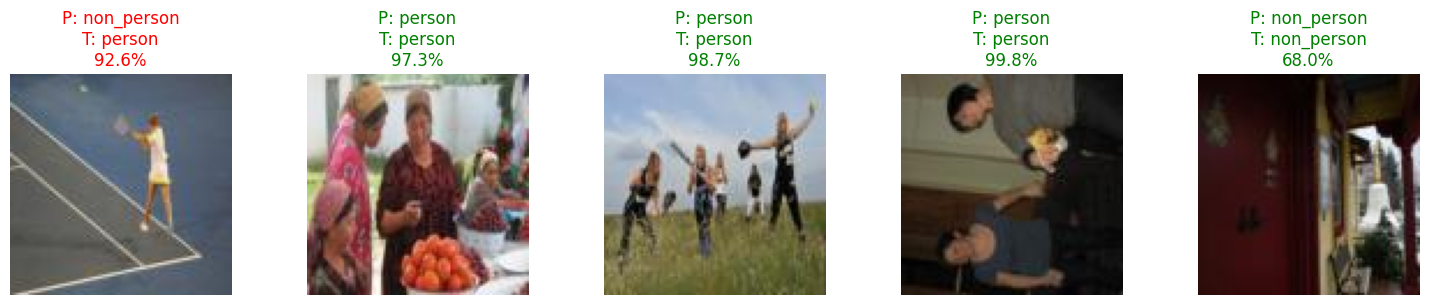

In [24]:
show_random_predictions(5)